In [6]:
import numpy as np
import math, copy
import matplotlib.pyplot as plt

In [ ]:
x_train = np.array([1.0, 2.0, 3.0, 4.0, 5.0])           
y_train = np.array([30.0, 50.0, 68.0, 75.0, 100.0])           

In [ ]:
def compute_cost(x, y, b, w):
    """
    Computes the cost function for linear regression.

    Args:
      x (ndarray (m,)): Data, m examples
      y (ndarray (m,)): target values
      b, w (scalar)    : theta_0 and theta_1, model parameters

    Returns
        total_cost (float): The cost of using theta_0, theta_1 as the parameters for linear regression
               to fit the data points in x and y
    """
    m = x.shape[0]

    cost_sum = 0

    for i in range(m):
        h_x = b + w * x[i]
        cost = (h_x - y[i]) ** 2
        cost_sum = cost_sum + cost

    total_cost = (1 / (2*m)) * cost_sum

    return total_cost

In [ ]:
def compute_gradient(x, y, w, b):
    """
    Computes the gradient for linear regression
    Args:
      x (ndarray (m,)): Data, m examples
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b
     """

    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        h_x = w * x[i] + b
        dj_dw_i = (h_x - y[i]) * x[i]
        dj_db_i = h_x - y[i]
        dj_db += dj_db_i
        dj_dw += dj_dw_i

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

In [ ]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    """
    Performs gradient descent to fit w,b. Updates w,b by taking
    num_iters gradient steps with learning rate alpha

    Args:
      x (ndarray (m,))  : Data, m examples
      y (ndarray (m,))  : target values
      w_in,b_in (scalar): initial values of model parameters
      alpha (float):     Learning rate
      num_iters (int):   number of iterations to run gradient descent
      cost_function:     function to call to produce cost
      gradient_function: function to call to produce gradient

    Returns:
      w (scalar): Updated value of parameter after running gradient descent
      b (scalar): Updated value of parameter after running gradient descent
      J_history (List): History of cost values
      p_history (list): History of parameters [w,b]
      """

    w = copy.deepcopy(w_in) 
    J_history = []
    p_history = []
    b = b_in
    w = w_in

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w , b)  #  YOUR CODE HERE

        
        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        if i<100000:      
            J_history.append( cost_function(x, y, w , b))
            p_history.append([w,b])

        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")

    return w, b, J_history, p_history 

In [11]:
w_init = 0
b_init = 0
iterations = 10000
tmp_alpha = 1.0e-2
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 2.08e+03  dj_dw: -2.268e+02, dj_db: -6.460e+01   w:  2.268e+00, b: 6.46000e-01
Iteration 1000: Cost 4.59e+01  dj_dw:  8.433e-02, dj_db: -3.045e-01   w:  1.700e+01, b: 1.33020e+01
Iteration 2000: Cost 1.59e+01  dj_dw:  1.553e-02, dj_db: -5.607e-02   w:  1.659e+01, b: 1.47689e+01
Iteration 3000: Cost 1.26e+01  dj_dw:  2.860e-03, dj_db: -1.033e-02   w:  1.652e+01, b: 1.50390e+01
Iteration 4000: Cost 1.21e+01  dj_dw:  5.268e-04, dj_db: -1.902e-03   w:  1.650e+01, b: 1.50888e+01
Iteration 5000: Cost 1.20e+01  dj_dw:  9.702e-05, dj_db: -3.503e-04   w:  1.650e+01, b: 1.50979e+01
Iteration 6000: Cost 1.20e+01  dj_dw:  1.787e-05, dj_db: -6.451e-05   w:  1.650e+01, b: 1.50996e+01
Iteration 7000: Cost 1.20e+01  dj_dw:  3.291e-06, dj_db: -1.188e-05   w:  1.650e+01, b: 1.50999e+01
Iteration 8000: Cost 1.20e+01  dj_dw:  6.060e-07, dj_db: -2.188e-06   w:  1.650e+01, b: 1.51000e+01
Iteration 9000: Cost 1.20e+01  dj_dw:  1.116e-07, dj_db: -4.029e-07   w:  1.650e+01, b: 1.51000e+01


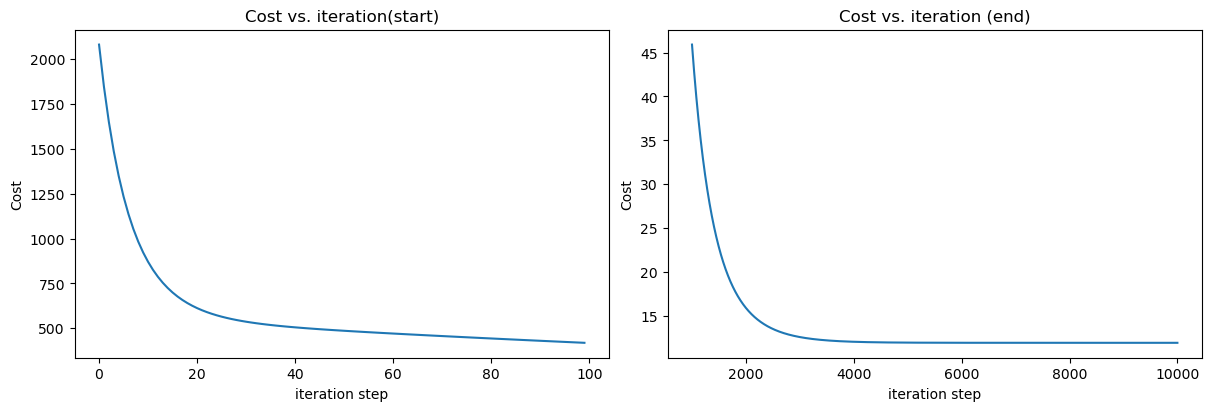

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost')
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step')
plt.show()

In [14]:
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand INR")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand INR")
print(f"1750 sqft house prediction {w_final*1.75 + b_final:0.1f} Thousand INR")

1000 sqft house prediction 31.6 Thousand INR
2000 sqft house prediction 48.1 Thousand INR
1750 sqft house prediction 44.0 Thousand INR
